In [1]:
from sand_bob import execute

code = """
from skimage.io import imread, imsave
from skimage.morphology import white_tophat, disk
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label
import numpy as np
image = imread('input_data/blobs.tif')
selem = disk(10)
processed_image = white_tophat(image, selem)
smoothed = gaussian(processed_image, sigma=2)
binary = smoothed > threshold_otsu(smoothed)
label_image = label(binary)
print(label_image.max())
"""
dependencies=["scikit-image", "numpy"]

res = execute(code, 
              dependencies=dependencies, 
              input_host_path="input_data")

res

ExecutionResult(stdout='[NbConvertApp] Converting notebook notebook.ipynb to notebook\n[NbConvertApp] Writing 1488 bytes to /display_output/notebook_executed.ipynb\n', stderr='', exit_code=0, execution_time=7.810495615005493, container_id='08f29a0d6e61c25c6b7903f3ea732089314e8fd7b4b631c4c14715a865a7d593', code='{\n "cells": [\n  {\n   "cell_type": "code",\n   "execution_count": null,\n   "metadata": {},\n   "outputs": [],\n   "source": [\n    "\\n",\n    "from skimage.io import imread, imsave\\n",\n    "from skimage.morphology import white_tophat, disk\\n",\n    "from skimage.filters import gaussian, threshold_otsu\\n",\n    "from skimage.measure import label\\n",\n    "import numpy as np\\n",\n    "image = imread(\'input_data/blobs.tif\')\\n",\n    "selem = disk(10)\\n",\n    "processed_image = white_tophat(image, selem)\\n",\n    "smoothed = gaussian(processed_image, sigma=2)\\n",\n    "binary = smoothed > threshold_otsu(smoothed)\\n",\n    "label_image = label(binary)\\n",\n    "print(label_image.max())\\n",\n    "\\n"\n   ]\n  }\n ],\n "metadata": {\n  "kernelspec": {\n   "display_name": "Python 3",\n   "language": "python",\n   "name": "python3"\n  },\n  "language_info": {\n   "codemirror_mode": {\n    "name": "ipython",\n    "version": 3\n   },\n   "file_extension": ".py",\n   "mimetype": "text/x-python",\n   "name": "python",\n   "nbconvert_exporter": "python",\n   "pygments_lexer": "ipython3",\n   "version": "3.8.0"\n  }\n },\n "nbformat": 4,\n "nbformat_minor": 4\n}', dependencies=['scikit-image', 'numpy'], traceback=None, files={'/display_output/notebook_executed.ipynb': b'{\n "cells": [\n  {\n   "cell_type": "code",\n   "execution_count": 1,\n   "metadata": {\n    "execution": {\n     "iopub.execute_input": "2025-08-08T12:31:57.505716Z",\n     "iopub.status.busy": "2025-08-08T12:31:57.505459Z",\n     "iopub.status.idle": "2025-08-08T12:31:58.094817Z",\n     "shell.execute_reply": "2025-08-08T12:31:58.094096Z"\n    }\n   },\n   "outputs": [\n    {\n     "name": "stdout",\n     "output_type": "stream",\n     "text": [\n      "56\\n"\n     ]\n    }\n   ],\n   "source": [\n    "\\n",\n    "from skimage.io import imread, imsave\\n",\n    "from skimage.morphology import white_tophat, disk\\n",\n    "from skimage.filters import gaussian, threshold_otsu\\n",\n    "from skimage.measure import label\\n",\n    "import numpy as np\\n",\n    "image = imread(\'input_data/blobs.tif\')\\n",\n    "selem = disk(10)\\n",\n    "processed_image = white_tophat(image, selem)\\n",\n    "smoothed = gaussian(processed_image, sigma=2)\\n",\n    "binary = smoothed > threshold_otsu(smoothed)\\n",\n    "label_image = label(binary)\\n",\n    "print(label_image.max())\\n",\n    "\\n"\n   ]\n  }\n ],\n "metadata": {\n  "kernelspec": {\n   "display_name": "Python 3",\n   "language": "python",\n   "name": "python3"\n  },\n  "language_info": {\n   "codemirror_mode": {\n    "name": "ipython",\n    "version": 3\n   },\n   "file_extension": ".py",\n   "mimetype": "text/x-python",\n   "name": "python",\n   "nbconvert_exporter": "python",\n   "pygments_lexer": "ipython3",\n   "version": "3.11.13"\n  }\n },\n "nbformat": 4,\n "nbformat_minor": 4\n}\n'}, n_attempts=None, result_check_ok=None, outputs=[{'type': 'text/plain', 'data': '56\n'}])

In [2]:
res.outputs

[{'type': 'text/plain', 'data': '56\n'}]

In [3]:
from sand_bob._code_gen import generate_code_feedback

feedback = generate_code_feedback(code, res.outputs)

In [4]:
from IPython.display import Markdown
display(Markdown(feedback))

**Code quality & style**  
- Group imports logically (standard library → third‑party).  
- Use explicit names for parameters (`sigma=2`, `disk_radius=10`).  
- Add short comments to explain each processing step.  
- Wrap the workflow in a function so it can be reused and tested.

**Error handling & sanity checks**  
- Verify that the file exists and that the image was loaded correctly.  
- Check that the image is grayscale (or convert it) before applying `white_tophat`.  
- After each major step, optionally print or log summary statistics (e.g., mean/std) to catch unexpected values.

**Documentation**  
- Add a docstring to the function describing inputs, outputs, and the overall pipeline.

**Image‑analysis best practice**  
- Show intermediate results (e.g., with `matplotlib.pyplot.imshow`) to confirm that each operation behaves as expected.  
- Use `dtype`‑aware thresholding: convert to float before `gaussian` if the input is integer‑typed.

**Suggested rewrite**

```python
# ----------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imsave
from skimage.morphology import white_tophat, disk
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label

def segment_blobs(
    path: str,
    disk_radius: int = 10,
    sigma: float = 2.0,
    show_steps: bool = False,
) -> np.ndarray:
    """
    Load a 2‑D image, apply white‑tophat background correction,
    smooth with a Gaussian filter, threshold using Otsu, and label connected components.

    Parameters
    ----------
    path : str
        Path to the input image (TIFF, PNG, …).
    disk_radius : int, default 10
        Radius of the structuring element for the white‑tophat operation.
    sigma : float, default 2.0
        Standard deviation for the Gaussian smoothing.
    show_steps : bool, default False
        If True, display intermediate results with ``matplotlib``.

    Returns
    -------
    label_image : np.ndarray
        Integer‑valued label image where each blob has a unique id.
    """
    img_path = pathlib.Path(path)
    if not img_path.is_file():
        raise FileNotFoundError(f"Image not found: {img_path}")

    # ------------------------------------------------------------------
    # Load image
    # ------------------------------------------------------------------
    image = imread(img_path)
    if image.ndim == 3:                     # convert RGB → grayscale if needed
        image = np.mean(image, axis=2)

    # ------------------------------------------------------------------
    # Background correction (white tophat)
    # ------------------------------------------------------------------
    selem = disk(disk_radius)
    processed = white_tophat(image, selem)

    # ------------------------------------------------------------------
    # Smoothing
    # ------------------------------------------------------------------
    # Ensure floating point arithmetic for Gaussian
    processed = processed.astype(float)
    smoothed = gaussian(processed, sigma=sigma)

    # ------------------------------------------------------------------
    # Thresholding
    # ------------------------------------------------------------------
    thresh = threshold_otsu(smoothed)
    binary = smoothed > thresh

    # ------------------------------------------------------------------
    # Label connected components
    # ------------------------------------------------------------------
    label_image = label(binary)

    if show_steps:
        fig, axs = plt.subplots(1, 5, figsize=(15, 3))
        titles = ["Original", "White‑tophat", "Smoothed", "Binary", "Labels"]
        images = [image, processed, smoothed, binary, label_image]
        for ax, img, ttl in zip(axs, images, titles):
            ax.imshow(img, cmap="gray")
            ax.set_title(ttl)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    return label_image


# ----------------------------------------------------------------------
# Example usage
# ----------------------------------------------------------------------
if __name__ == "__main__":
    lbl = segment_blobs("input_data/blobs.tif", show_steps=True)
    print(f"Number of detected blobs: {lbl.max()}")
```

**What changed & why**

1. **Function encapsulation** – makes the code reusable and testable.  
2. **File existence check** – raises a clear error if the image is missing.  
3. **Grayscale conversion guard** – avoids shape mismatches for color images.  
4. **Explicit dtype conversion** before `gaussian` to prevent integer overflow.  
5. **Intermediate visualisation (`show_steps=True`)** – lets you verify each processing stage.  
6. **Docstring & type hints** – improve readability and help IDEs/static analysis.  
7. **PEP‑8 compliant layout** – line lengths, import ordering, spacing.  

These adjustments keep the core algorithm unchanged while making the notebook cell safer, easier to understand, and more maintainable.

ExecutionResult(stdout='[NbConvertApp] Converting notebook notebook.ipynb to notebook\n[NbConvertApp] Writing 315155 bytes to /display_output/notebook_executed.ipynb\n', stderr='', exit_code=0, execution_time=49.54249954223633, container_id='66f8c0fb29d25cdeaa12aa6983b3b682634905d5aa71f1b9533292822c7f19ed', code='# ----------------------------------------------------------------------\n# Imports\n# ----------------------------------------------------------------------\nimport pathlib\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom skimage.io import imread, imsave\nfrom skimage.morphology import white_tophat, disk\nfrom skimage.filters import gaussian, threshold_otsu\nfrom skimage.measure import label\n\ndef segment_blobs(\n    path: str,\n    disk_radius: int = 10,\n    sigma: float = 2.0,\n    show_steps: bool = False,\n) -> np.ndarray:\n    """\n    Load a 2‑D image, apply white‑tophat background correction,\n    smooth with a Gaussian filter, threshold using Otsu, and label connected components.\n\n    Parameters\n    ----------\n    path : str\n        Path to the input image (TIFF, PNG, …).\n    disk_radius : int, default 10\n        Radius of the structuring element for the white‑tophat operation.\n    sigma : float, default 2.0\n        Standard deviation for the Gaussian smoothing.\n    show_steps : bool, default False\n        If True, display intermediate results with ``matplotlib``.\n\n    Returns\n    -------\n    label_image : np.ndarray\n        Integer‑valued label image where each blob has a unique id.\n    """\n    img_path = pathlib.Path(path)\n    if not img_path.is_file():\n        raise FileNotFoundError(f"Image not found: {img_path}")\n\n    # ------------------------------------------------------------------\n    # Load image\n    # ------------------------------------------------------------------\n    image = imread(img_path)\n    if image.ndim == 3:                     # convert RGB → grayscale if needed\n        image = np.mean(image, axis=2)\n\n    # ------------------------------------------------------------------\n    # Background correction (white‑tophat)\n    # ------------------------------------------------------------------\n    selem = disk(disk_radius)\n    processed = white_tophat(image, selem)\n\n    # ------------------------------------------------------------------\n    # Smoothing\n    # ------------------------------------------------------------------\n    processed = processed.astype(float)    # ensure floating point for Gaussian\n    smoothed = gaussian(processed, sigma=sigma)\n\n    # ------------------------------------------------------------------\n    # Thresholding\n    # ------------------------------------------------------------------\n    thresh = threshold_otsu(smoothed)\n    binary = smoothed > thresh\n\n    # ------------------------------------------------------------------\n    # Label connected components\n    # ------------------------------------------------------------------\n    label_image = label(binary)\n\n    if show_steps:\n        fig, axs = plt.subplots(1, 5, figsize=(15, 3))\n        titles = ["Original", "White‑tophat", "Smoothed", "Binary", "Labels"]\n        images = [image, processed, smoothed, binary, label_image]\n        for ax, img, ttl in zip(axs, images, titles):\n            ax.imshow(img, cmap="gray")\n            ax.set_title(ttl)\n            ax.axis("off")\n        plt.tight_layout()\n        plt.show()\n\n    return label_image\n\n\n# ----------------------------------------------------------------------\n# Example usage\n# ----------------------------------------------------------------------\nif __name__ == "__main__":\n    lbl = segment_blobs("input_data/blobs.tif", show_steps=True)\n    print(f"Number of detected blobs: {lbl.max()}")\n    # Display the label image in the notebook\n    display(lbl)', dependencies=['scikit-image', 'numpy', 'numpy', 'matplotlib', 'scikit-image'], traceback=None, files={'/display_output/noteb
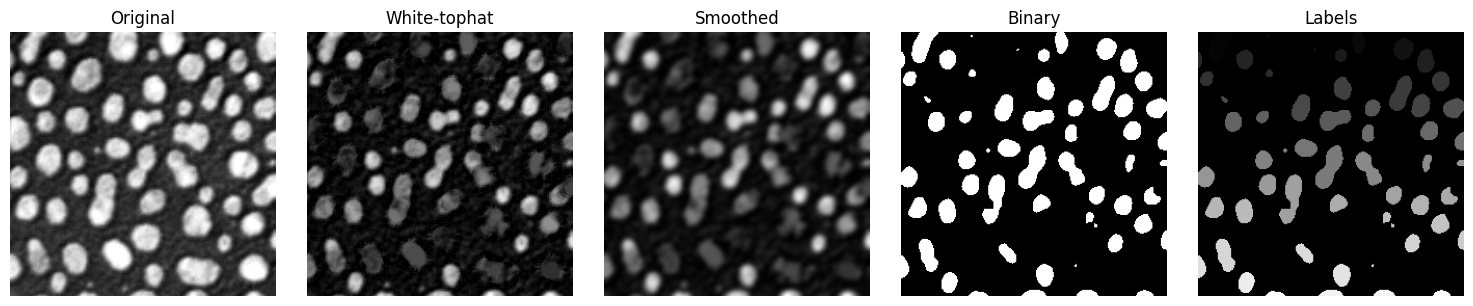

In [5]:
from sand_bob._code_gen import generate_run

res2 = generate_run(f"""
Given some code and detailed feedback, propose new code that incroporates the feedback.

# Code

```
{code}
```

# Feedback

{feedback}

# Your task
Provide the updated code which incorporates the feedback. Skip all explanations.
""", dependencies=dependencies, input_host_path="input_data")

res2